# Linear Regression

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [5]:
#Import Points
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

In [6]:
df

,x,y
0,1,5
1,2,10
2,3,10
3,4,15
4,5,14
5,6,15
6,7,19
7,8,18
8,9,25
9,10,23


In [12]:
#Extract imputs variables
X = df.values[:, :-1]  #All rows, all columns but last column
#Extract output values
Y = df.values[:, -1] # all rows, las column

In [15]:
#fit a line to the point
fit = LinearRegression().fit(X, Y)

In [16]:
# m=1.78, b = -16.5
m = fit.coef_.flatten()
b = fit.intercept_.flatten()
print(f'm = {m}')
print(f'b = {b}')

m = [1.93939394]
b = [4.73333333]


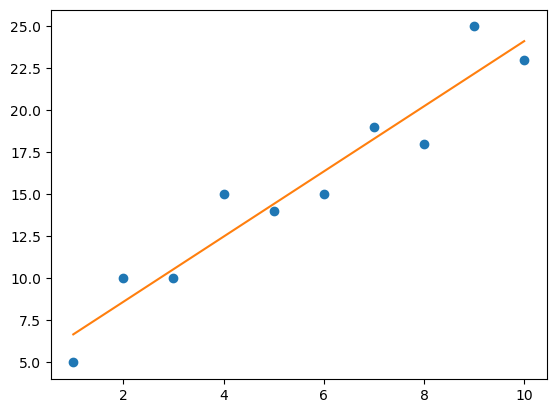

In [20]:
#show chart
plt.plot(X, Y, 'o') #Scatterplot
plt.plot(X, m*X+b) #Line
plt.show()

### Residuals and squared errors 

In [21]:
#best fit = we minimize the squares /the sum of the sauqred residuals

In [22]:
import pandas as pd

In [55]:
points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",").itertuples()
points

In [53]:
#Test with a given line
m = 1.93939
b = 4.73333

In [54]:
#Calculate residuals
for p in points:
    y_actual = p.y
    y_predict = m * p.x+ b
    residual = y_actual - y_predict
    print(residual)

-1.67272
1.3878900000000005
-0.5515000000000008
2.5091099999999997
-0.4302799999999998
-1.3696699999999993
0.6909400000000012
-2.2484499999999983
2.812160000000002
-1.1272299999999973


In [ ]:
#Sumof squares for a given line and data 

In [51]:
points = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples()

#Test with a given line
m = 1.93939
b = 4.73333

sum_of_squares = 0.0

#Calculate sum of squares
for p in points:
    y_actual = p.y
    y_predict = m * p.x+ b
    residual_squares = (y_actual - y_predict)**2
    sum_of_squares += residual_squares
    
print(f'sum of squares = {sum_of_squares}')

sum of squares = 28.096969704500005


#### Finding the best fit Line 

In [56]:
#The sum ofsquares =the lower we can make that number, the better fit

In [57]:
#Calculating m and b for a simple linear regression 

In [64]:
points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

n = len(points)

m = (n*sum(p.x*p.y for p in points) - sum(p.x for p in points) * sum(p.y for p in points)) / (n*sum(p.x**2 for p in points) - sum(p.x for p in points)**2)

b = (sum(p.y for p in points) / n) - m * sum(p.x for p in points) / n

print(m,b)

1.9393939393939394 4.7333333333333325


#### Inverse Matrix Technique 

In [65]:
#b = (X**T . X)**-1 . X**T . y

In [38]:
import pandas as pd
from numpy.linalg import inv
import numpy as np

points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

X = points.values[:,:-1].flatten()
#Add placeholder 1 column to generate intercept
X_1 = np.vstack([X, np.ones(len(X))]).T
Y = points.values[:,-1]

#coeficients
b = inv(X_1.T @ X_1) @ (X_1.T @ Y)
print(b)

#Predict againt y-values
y_predict = X_1.dot(b)
y_predict

[1.93939394 4.73333333]


array([ 6.67272727,  8.61212121, 10.55151515, 12.49090909, 14.43030303,
       16.36969697, 18.30909091, 20.24848485, 22.18787879, 24.12727273])

In [1]:
import pandas as pd
from numpy.linalg import inv
import numpy as np

points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

In [47]:
X = points.values[:,:-1].flatten()
Y = points.values[:,-1]
X1 = np.ones(len(X))

X2 = np.concatenate((X.reshape(-1,1), X1.reshape(-1,1)), axis=1)

B = inv(X2.T @ X2) @ (X2.T @ Y)
B

array([1.93939394, 4.73333333])

#### Matrix Decomposition 

In [48]:
# X = Q . R
# b = R**-1 . Q**T . y

In [50]:
import pandas as pd 
import numpy as np
from numpy.linalg import inv, qr

In [57]:
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

X = df.values[:,:-1].flatten() 
X1 = np.vstack([X, np.ones(len(X))]).T

Y = df.values[:,-1].flatten() 

#Using QR Decomposition
Q,R = qr(X1)
b = inv(R).dot(Q.transpose()).dot(Y)

print(b)

[1.93939394 4.73333333]


### Gradient Descent 

In [12]:
import random

def f(x):
    return (x - 3) ** 2 + 4

def dx_f(x):
    return 2 * (x - 3)

#The learning rate
L = 0.001

#The number of iterations to perform gradient decent
iterations = 100_000
#start ar rando x
x = random.randint(-15,15)


for i in range(iterations):
    #get slope
    d_x = dx_f(x)
    #update x by substracting the (learning rate) * (slope)
    x -= L * d_x
    print(x)
    
print(x, f(x))

-8.976
-8.952048000000001
-8.928143904
-8.904287616192
-8.880479040959617
-8.856718082877698
-8.833004646711943
-8.80933863741852
-8.785719960143682
-8.762148520223395
-8.738624223182947
-8.715146974736582
-8.691716680787108
-8.668333247425533
-8.644996580930682
-8.62170658776882
-8.598463174593283
-8.575266248244096
-8.552115715747608
-8.529011484316113
-8.505953461347481
-8.482941554424785
-8.459975671315936
-8.437055719973305
-8.414181608533358
-8.391353245316292
-8.36857053882566
-8.345833397748008
-8.323141730952512
-8.300495447490608
-8.277894456595627
-8.255338667682436
-8.23282799034707
-8.210362334366376
-8.187941609697644
-8.165565726478249
-8.143234595025293
-8.120948125835243
-8.098706229583572
-8.076508817124404
-8.054355799490155
-8.032247087891175
-8.010182593715394
-7.988162228527963
-7.966185904070906
-7.944253532262764
-7.922365025198239
-7.900520295147842
-7.878719254557547
-7.856961816048432
-7.8352478924163345
-7.813577396631501
-7.791950241838238
-7.77036634135456

2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.999999999999889
2.99999999

#### Gradient Decent for a Linear Regression

In [24]:
import pandas as pd 
import matplotlib.pyplot as plt

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

y = 1.9393939393939548 x + 4.733333333333227


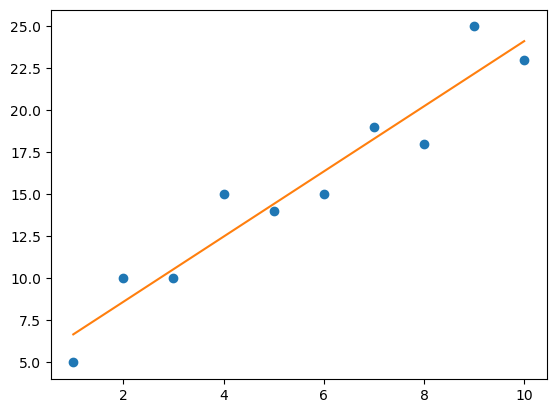

In [28]:
#building the model
m = 0.0
b = 0.0

#Learning Rate and iterations
L = 0.001
iterations = 100_000

n = float(len(points)) #Number of elements in X

#Perform gradient decent
for i in range(iterations):
    #slope with respect to m
    D_m = sum(2 * p.x * ((m * p.x + b) - p.y)for p in points)
    
    #slope with respect to b
    D_b = sum(2 * ((m * p.x + b) - p.y) for p in points)
    
    #update m and b
    m -= L * D_m
    b -= L * D_b
    
print(f'y = {m} x + {b}')

#show chart
X = data.iloc[:,0].values
Y = data.iloc[:,1].values

plt.plot(X, Y, 'o') #Scatterplot
plt.plot(X, m*X+b) #Line
plt.show()

In [82]:
#Using Sympy

from sympy import *

m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)
sum_of_squares = Sum((m * x(i) + b - y(i)) ** 2, (i, 0, n))

d_m = diff(sum_of_squares, m)
d_b = diff(sum_of_squares, b)

print(d_m)
print(d_b)

Sum(2*(b + m*x(i) - y(i))*x(i), (i, 0, n))
Sum(2*b + 2*m*x(i) - 2*y(i), (i, 0, n))


In [95]:
points = [(1,2), (2,4), (3,6)]
m = 1
b = 2

for x, y in points:
    error = (m*x + b) - y
    
    print(error)

1
0
-1


In [99]:
# Solving Linear Regression
import pandas as pd
from sympy import *

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)

sum_of_squares = Sum((m * x(i) + b - y(i)) ** 2, (i, 0, n))

d_m = diff(sum_of_squares, m).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)
d_b = diff(sum_of_squares, b).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)

#Compile using lambdify for faster computation
d_m = lambdify([m, b], d_m)
d_b = lambdify([m, b], d_b)

#Building the model
m = 0.0
b = 0.0

#The leraning rate and iterations
L = 0.001
interations= 100_000

#Perform Gradient Decent
for i in range(iterations):
    #update m and b
    m -= d_m(m,b) * L
    b -= d_b(m,b) * L

print(f'y = {m} x + {b}')

y = 1.939393939393954 x + 4.733333333333231


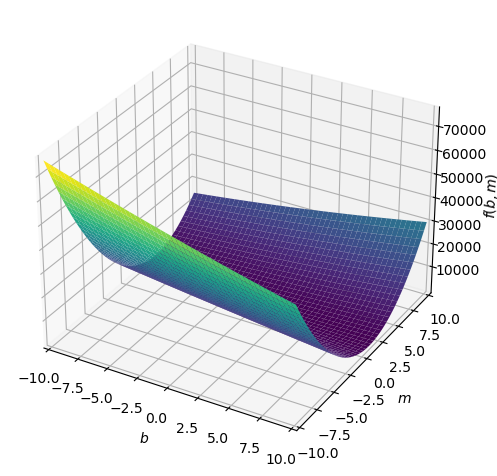

In [102]:
#Plotting the loss function 
from sympy import *
from sympy.plotting import plot3d
import pandas as pd

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)

sum_of_squares = Sum((m * x(i) + b - y(i)) ** 2, (i, 0, n)).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)

plot3d(sum_of_squares)

### StochasticGradient Descent

In [1]:
import pandas as pd 
import numpy as np

In [13]:
data = pd.read_csv('https://bit.ly/2KF29Bd', header=0)
X = data.iloc[:,0].values
Y = data.iloc[:,1].values

n = data.shape[0] #rows

#Building the model
m = 0.0
b = 0.0

sample_size = 5 #sample size
L = 0.0001 #Learning Rate
epochs = 1_000_000 #number of iterations to perform gradient decent

#Performing stochastic gradient descent
for i in range(epochs):
    idx = np.random.choice(n, sample_size, replace=False)
    x_sample = X[idx]
    y_sample = Y[idx]
    
    ##Thecurrent predicted value of Y
    Y_pred = m * x_sample + b
    #d/dm derivative of loss function
    D_m = (-2 / sample_size) * sum(x_sample * (y_sample - Y_pred))
    
    #d/db derivative of loss function
    D_b = (-2 / sample_size) * sum(y_sample - Y_pred)
    m = m - L * D_m #Updated m
    b = b - L * D_b #Updated b
    
    #print Progress
    if i % 10000 == 0:
        print(i, m, b)
        
print(f'y = {m} x + {b}')

0 0.0082 0.0022
10000 2.363954420743905 1.8589392180188962
20000 2.2074069774286325 2.8428548271923355
30000 2.129711109893787 3.484600018136347
40000 2.0567452303996596 3.910525714520804
50000 2.0162863273146456 4.192660986097576
60000 1.9939432109310185 4.374068385499803
70000 1.972697717989369 4.498520851386994
80000 1.947135366063563 4.567364262458355
90000 1.9524651971843672 4.628710149266162
100000 1.9575397117144469 4.658070675882176
110000 1.9553537266376144 4.688227618675109
120000 1.9474288829389756 4.701968369889139
130000 1.9455985894217331 4.716774310350206
140000 1.9421939310381897 4.723085806497123
150000 1.9460787958828745 4.726049323168588
160000 1.947676750407898 4.729636636905072
170000 1.9400761515971139 4.732156116309935
180000 1.9293576369547851 4.730975438252921
190000 1.9416657576785568 4.732942484417902
200000 1.9447223022464948 4.735232781079791
210000 1.9361573003633465 4.737381767518986
220000 1.9383988254093054 4.73940326354233
230000 1.9366061780679522 4.7

### Correlation Coeficient

In [14]:
#Correlation coefficient = Perason correlation -> mesures the strenght of the 
#relationship between two variables as a value between -1 and 1
#closer to 0 = No correlation
#closer to 1 = Strong positive correlation -> when one variable increases the other proportionally increases
#closer to -1 = Strong negative correlation -> as one variable increases the other proportionally decreases

In [17]:
df = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",")

#Print correlations between variables
correlations = df.corr(method='pearson')
print(correlations)

          x         y
x  1.000000  0.957586
y  0.957586  1.000000


In [20]:
#From Scratch
import pandas as pd
from math import sqrt

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())
n =len(points)

numerator = n * sum(p.x * p.y for p in points) - sum(p.x for p in points) * sum(p.y for p in points)

denomidator = sqrt(n*sum(p.x**2 for p in points) - sum(p.x for p in points)**2) * sqrt(n*sum(p.y**2 for p in points) - sum(p.y for p in points)**2)

corr = numerator / denomidator
print(corr)

0.9575860952087218


### Statistical Significance 

In [31]:
#If our test value falls outside the critical range of 95% confidence, we acept that our correlation was not by chance

In [30]:
from scipy.stats import t 

n = 10
lower_cv = t(n-1).ppf(0.025)
upper_cv = t(n-1).ppf(0.975)

print(lower_cv, upper_cv)

-2.262157162740992 2.2621571627409915


In [33]:
#correlation coefficient derived from data
r = 0.957586

#Perform the test
test_value = r / sqrt((1-r**2) / (n--2))

print(f'Test value: {test_value}')
print(f'Critical Range: {lower_cv, upper_cv}')

if test_value < lower_cv or test_value > upper_cv:
    print("Correlation proven, reject H0")
else:
    print("Correlation proven, Failed to reject H0")
    
#Calculate p-value
if test_value >  0:
    p_value = 1.0 - t(n-1).cdf(test_value)
else:
    p_value = t(n-1).cdf(test_value)
    
#Two tailed, so multiply by 2 
p_value = p_value * 2
print(f'P-Value: {p_value}')

Test value: 11.512068624503032
Critical Range: (-2.262157162740992, 2.2621571627409915)
Correlation proven, reject H0
P-Value: 1.0957291567414984e-06


In [34]:
#The more data you have that consistently resembles a line, the more significant the p-value for your correlation
#The more scattered orsparsethe data, the more the p-value will increase and thus indicate your correlation ocurred by random chance

#### Coeficient of Determination 

In [35]:
#r approaches a perfect correlation (-1 or 1)
#r**2 aproaches 1 -> shows how much two variables interact with each other

In [36]:
df = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",")

#print correlations between variables
coeff_determination = df.corr(method='pearson') ** 2
print(coeff_determination)

          x         y
x  1.000000  0.916971
y  0.916971  1.000000


In [38]:
#91.69...% of the variation in x is explained by y and the remaining 8.3...% is noise caused by 
#other uncapured variables
# correlation != causation

#### Standard Error of the Estimate  

In [2]:
import pandas as pd
from math import sqrt

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

n = len(points)

#Regression Line
m = 1.939
b = 4.733

#Calculate Standard of Estimate
S_e = sqrt((sum((p.y - (m*p.x + b))**2 for p in points)) / (n-2))

print(S_e)

1.87406793500129


#### Prediction Intervals 

In [3]:
import pandas as pd
from math import sqrt
from scipy.stats import t

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

n = len(points)

#Regression Line
m = 1.939
b = 4.733

#Calculate Prediction Intervals for x = 8.5
x_0 = 8.5
x_mean = sum(p.x for p in points) / len(points)

t_value = t(n - 2).ppf(0.975)

standard_error = sqrt(sum((p.y - (m * p.x + b))**2 for p in points) / (n - 2))

margin_of_error = t_value * standard_error * sqrt(1 + (1/n) +(n *(x_0 - x_mean)**2) / 
                                                  (n * sum(p.x**2 for p in points) - sum(p.x for p in points)**2))

predicted_y = m*x_0 +b

#Calculate prediction interval
print(predicted_y - margin_of_error, predicted_y + margin_of_error)

16.462516875955465 25.966483124044537


### Train Test Split 

In [24]:
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#Load Data
df = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",")

#Extract input and variables
X = df.values[:,:-1]
Y = df.values[:,-1]

#Separate training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3)

model = LinearRegression()
model.fit(X_train, Y_train)

result = model.score(X_test, Y_test)
print("r**2: %.3f" % result)

r**2: 0.867


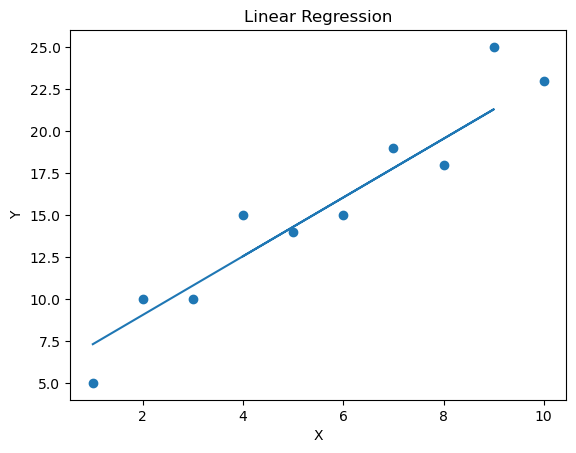

In [25]:
import matplotlib.pyplot as plt

# Predicciones
Y_pred = model.predict(X_test)

plt.scatter(X,Y)
#lt.scatter(X_test, Y_test)
plt.plot(X_test, Y_pred)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")

plt.show()

In [28]:
#Using three fold cross validation for a linear regression

import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

#Load Data
df = pd.read_csv('https://bit.ly/3cIH97A', delimiter=",")

#Extract input and variables
X = df.values[:,:-1]
Y = df.values[:,-1]

#Perform simple linear regressio 
kfold = KFold(n_splits=3, random_state=7, shuffle=True)
model = LinearRegression()

results = cross_val_score(model, X, Y, cv=kfold)
print(results)

print("MSE: mean=%.3f (stdev-%.3f)" % (results.mean(), results.std()))

[0.99337354 0.99345032 0.99251425]
MSE: mean=0.993 (stdev-0.000)


In [29]:
#Using random fold validation for a linear regression

import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, ShuffleSplit

#Load Data
df = pd.read_csv('https://bit.ly/38XwbeB', delimiter=",")

#Extract input and variables
X = df.values[:,:-1]
Y = df.values[:,-1]

#Perform simple linear regressio 
kfold = ShuffleSplit(n_splits=10, test_size=0.33, random_state=7)
model = LinearRegression()

results = cross_val_score(model, X, Y, cv=kfold)
print(results)

print("mean=%.3f (stdev-%.3f)" % (results.mean(), results.std()))

[0.82514286 0.23552344 0.92653455 0.91620594 0.73260142 0.8698865
 0.55254014 0.89593526 0.91570078 0.82086621]
mean=0.769 (stdev-0.208)


### Multiple Linear Regression 

In [31]:
import pandas as pd 
from sklearn.linear_model import LinearRegression

#Load Data
df = pd.read_csv('https://bit.ly/2X1HWH7', delimiter=",")

#Extract input and variables
X = df.values[:,:-1]
Y = df.values[:,-1]

fit = LinearRegression().fit(X,Y)

print(f'Coefficients = {fit.coef_}')
print(f'Intercept = {fit.intercept_}')
print(f'z = {fit.intercept_} + {fit.coef_[0]} x + {fit.coef_[1]} y')

Coefficients = [2.00672647 3.00203798]
Intercept = 20.10943282003599
z = 20.10943282003599 + 2.0067264725128062 x + 3.002037976646691 y


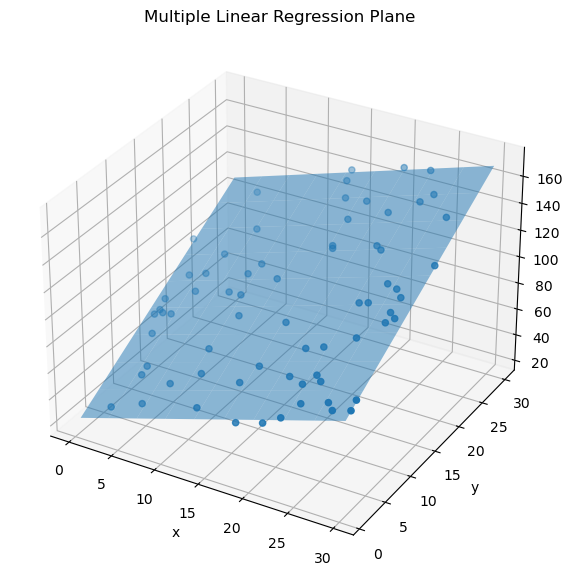

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load Data
df = pd.read_csv('https://bit.ly/2X1HWH7', delimiter=",")

# Variables
X = df.values[:, :-1]
Y = df.values[:, -1]

# Modelo
fit = LinearRegression().fit(X, Y)

# Crear figura 3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Puntos reales
ax.scatter(X[:,0], X[:,1], Y)

# Crear malla para el plano
x_range = np.linspace(X[:,0].min(), X[:,0].max(), 10)
y_range = np.linspace(X[:,1].min(), X[:,1].max(), 10)

x_grid, y_grid = np.meshgrid(x_range, y_range)

# Calcular z del plano
z_grid = (
    fit.intercept_
    + fit.coef_[0] * x_grid
    + fit.coef_[1] * y_grid
)

# Dibujar plano
ax.plot_surface(x_grid, y_grid, z_grid, alpha=0.5)

# Labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.title("Multiple Linear Regression Plane")

plt.show()

## Exercises 

In [24]:
import pandas as pd 
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('https://bit.ly/3C8JzrM', delimiter=",")

#X = df.values[:,:-1].flatten()
X = df.values[:,:-1].reshape(-1,1)
Y = df.values[:,-1]

X1 = np.vstack([np.ones(len(X)).T,X.T]).T

solution = inv(X1.T @ X1) @ X1.T @ Y
print(f'solution = {solution[0]} + {solution[1]} x')

solution = 4.6935965482540905 + 1.7591931481052476 x


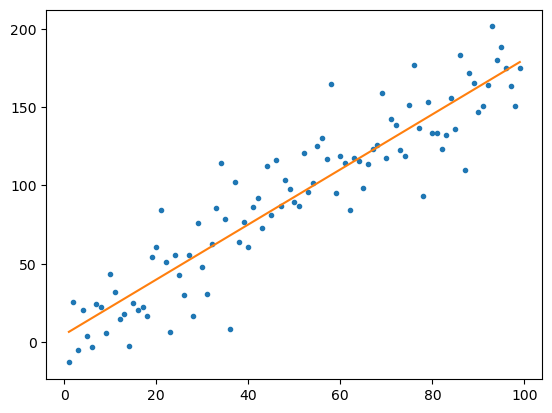

In [27]:
plt.plot(X, Y, '.')
plt.plot(X, solution[0] + solution[1]*X)

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv('https://bit.ly/3C8JzrM', delimiter=",")

#X = df.values[:,:-1].flatten()
X = df.values[:,:-1].reshape(-1,1)
Y = df.values[:,-1]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=1/3)

model = LinearRegression()
model.fit(X_train, Y_train)

result = model.score(X_test, Y_test)
result

0.824172323511211

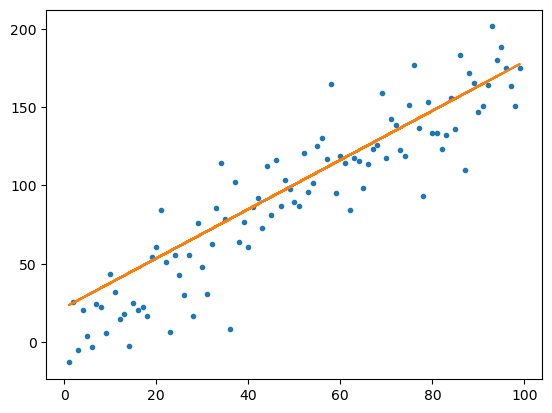

In [40]:
Y_predic = model.predict(X_test)

plt.plot(X,Y, '.')
plt.plot(X_test, Y_predic)